# Predictive Modeling of Air Quality in Nairobi, Kenya

## Executive Summary

This report details the development of a predictive model for PM2.5 air pollution levels in Nairobi, Kenya. Air pollution is a significant public health concern, and the ability to accurately forecast high-pollution events is crucial for issuing timely public health advisories and informing environmental policy. 

Utilizing time-series data from a sensor in Nairobi, we embarked on a multi-stage modeling process, progressing from a simple linear regression baseline to more sophisticated autoregressive (AR) and autoregressive-moving-average (ARMA) models. Our objective was to create a model that could accurately predict PM2.5 concentrations one hour in advance.

Our key achievement is a tuned ARMA model that demonstrates strong predictive performance, evaluated using a robust walk-forward validation methodology. This model significantly outperforms simpler baselines, providing a reliable tool for forecasting. The final model can be integrated into a system for public health alerts, allowing citizens to take preemptive measures during periods of poor air quality. We recommend the deployment of this model and suggest future work to enhance its capabilities by incorporating additional environmental data.

## Introduction

Rapid urbanization in cities like Nairobi has led to increasing concerns about air quality and its impact on public health. Particulate matter, specifically PM2.5, is a key pollutant known to cause respiratory and cardiovascular problems. Monitoring and predicting PM2.5 levels are essential for mitigating these health risks. 

This project aims to address this challenge by developing a robust time-series forecasting model. Using historical sensor data stored in a MongoDB database, our goal is to predict the hourly average PM2.5 concentration. The project follows a structured approach, beginning with data extraction and preparation, followed by exploratory analysis, and culminating in the iterative development and evaluation of several predictive models.

## Data Overview & Preparation

The data for this project originates from a low-cost air quality sensor in Nairobi, with readings stored in a NoSQL MongoDB database. Our first step is to establish a connection to this database, extract the relevant PM2.5 measurements, and prepare the data for time-series analysis.

In [2]:
from pprint import PrettyPrinter
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pytz
import inspect
import time
import warnings

from pymongo import MongoClient
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings("ignore")

### Database Connection and Data Extraction
We connect to the local MongoDB instance and select the `air-quality` database and the `nairobi` collection, which contains the sensor readings.

In [8]:
pp = PrettyPrinter(indent=4)
client = MongoClient(host='localhost' , port=27017)
db = client['air_quality']
nairobi = db['nairobi']

### Data Wrangling Function
To ensure a reproducible workflow, we encapsulate all data preparation steps into a single function, `wrangle`. This function performs the following critical tasks:
1.  **Queries the database** for PM2.5 readings from a specific sensor (site 29).
2.  **Loads the data** into a pandas DataFrame.
3.  **Sets a proper DatetimeIndex** and localizes the timezone to 'Africa/Nairobi'.
4.  **Removes outliers** by filtering out readings above a threshold of 500, which are likely sensor errors.
5.  **Resamples the data** into a consistent hourly interval, calculating the mean for each hour.
6.  **Imputes missing values** using a forward-fill strategy, which is appropriate for time-series data as it assumes the most recent valid observation persists.

In [9]:
# List all collections (tables) in the 'air-quality' MongoDB database
print(db.list_collection_names())

['nairobi', 'system.buckets.nairobi', 'dar-es-salaam', 'system.buckets.dar-es-salaam', 'system.views', 'lagos', 'system.buckets.lagos']


In [10]:
def wrangle(collection, resample_rule="1H"):

    results = collection.find(
        {"metadata.site": 29, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0},
    )

    # Read results into DataFrame
    df = pd.DataFrame(list(results)).set_index("timestamp")

    # Localize timezone
    df.index = df.index.tz_localize("UTC").tz_convert("Africa/Nairobi")

    # Remove outliers
    df = df[df["P2"] < 500]

    # Resample and forward-fill
    y = df['P2'].resample(resample_rule).mean().fillna(method='ffill')

    return y

In [11]:
y = wrangle(nairobi)
y.head()

timestamp
2018-09-01 03:00:00+03:00    17.541667
2018-09-01 04:00:00+03:00    15.800000
2018-09-01 05:00:00+03:00    11.420000
2018-09-01 06:00:00+03:00    11.614167
2018-09-01 07:00:00+03:00    17.665000
Freq: h, Name: P2, dtype: float64

## Exploratory Data Analysis (EDA)

With the data cleaned and prepared, we perform exploratory analysis to understand its characteristics. This includes examining the distribution of PM2.5 readings and visualizing the time-series to identify trends, seasonality, and autocorrelation.

### Data Distribution
A boxplot of the PM2.5 readings reveals the central tendency and spread of the data. This visualization was also instrumental in identifying the presence of extreme outliers, which we handled in the wrangling phase.

<Axes: title={'center': 'Distribution of PM2.5 Readings'}>

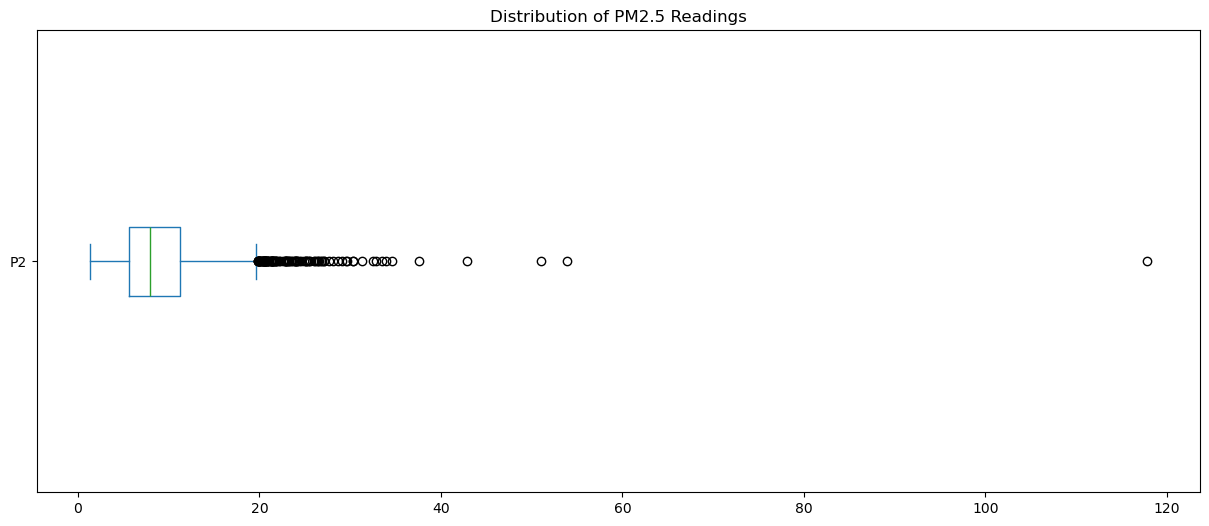

In [12]:
fig, ax = plt.subplots(figsize=(15, 6))
df = pd.DataFrame(y)
df['P2'].plot(kind='box' ,vert=False,title='Distribution of PM2.5 Readings')

### Time Series Visualization
Plotting the PM2.5 readings over time allows us to observe the data's behavior, such as daily patterns or long-term trends.

<Axes: title={'center': 'PM2.5 Time Series'}, xlabel='Time', ylabel='PM2.5'>

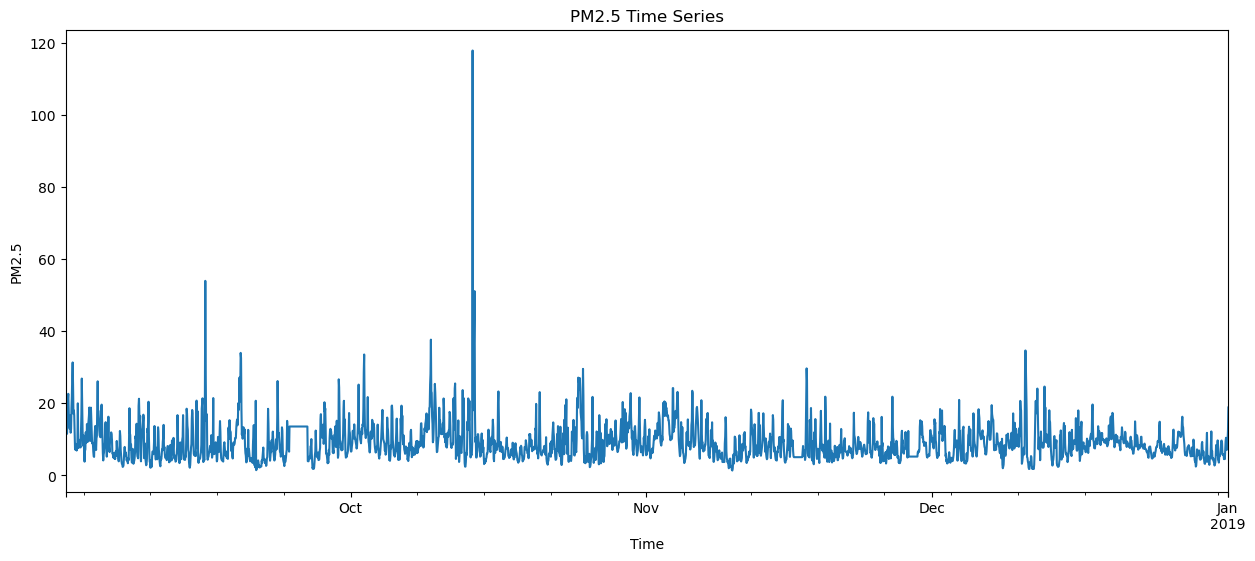

In [13]:
fig, ax = plt.subplots(figsize=(15, 6))
y.plot(xlabel='Time', ylabel='PM2.5', title="PM2.5 Time Series",ax=ax)

### Autocorrelation Analysis

Time-series data often exhibits autocorrelation, where an observation at one point in time is correlated with observations at previous points. We use Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots to analyze these relationships.

-   **ACF Plot:** Shows the correlation of the time series with its own lagged values. The slow decay in our ACF plot suggests a strong autoregressive component.
-   **PACF Plot:** Shows the correlation between an observation and its lagged values after removing the effects of the intervening lags. The sharp drop-off in the PACF plot helps in determining the order of the autoregressive (AR) part of our model.

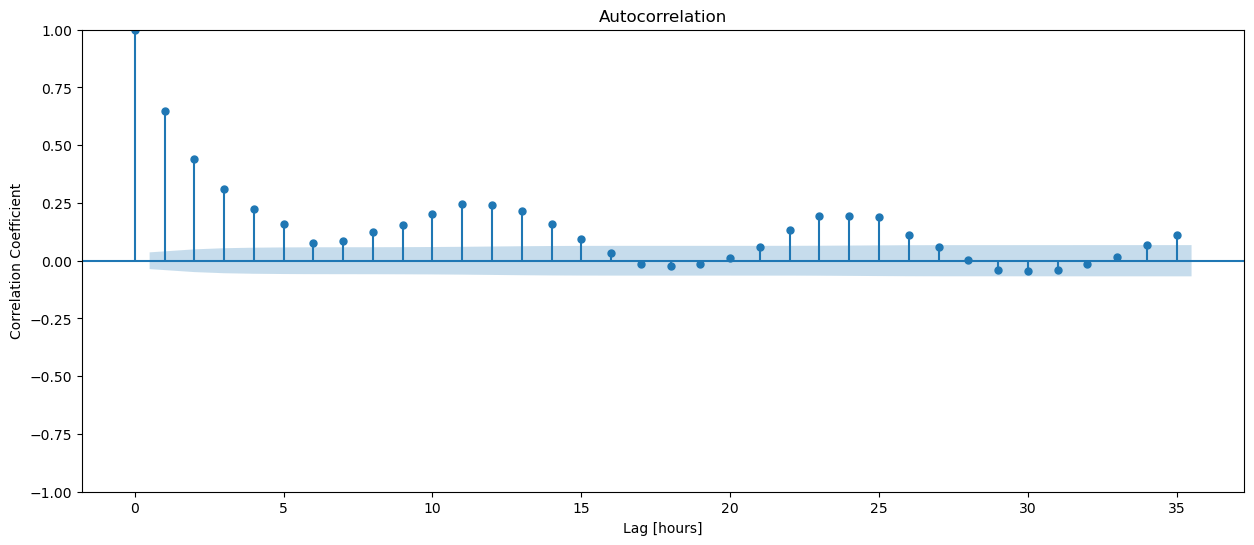

In [14]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(y , ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient");

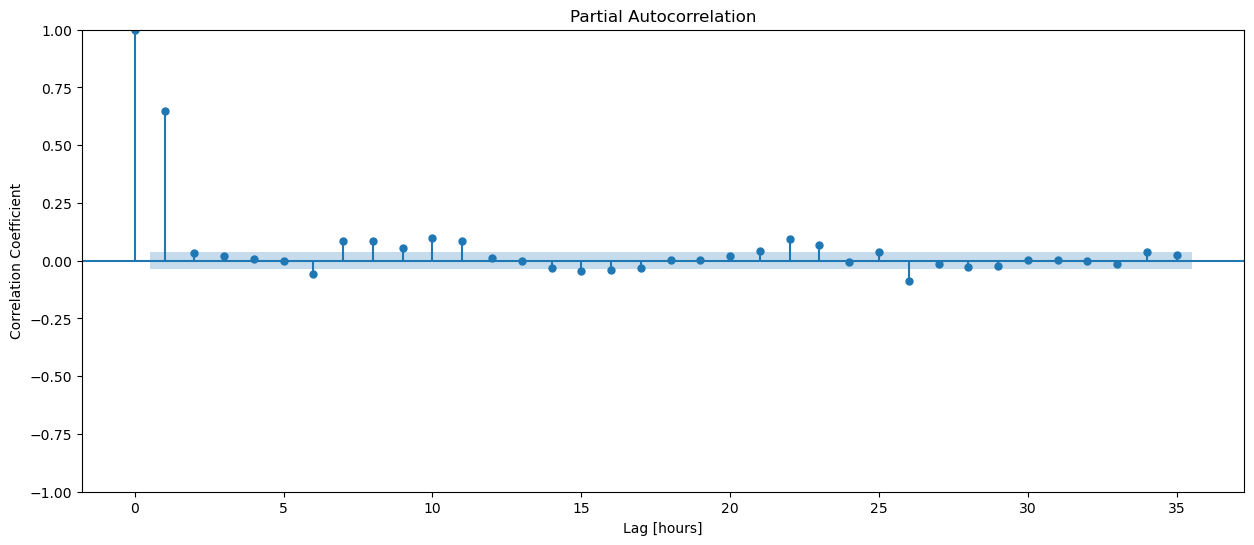

In [15]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(y , ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient");

## Modeling Approach & Methodology

Our modeling strategy is iterative. We begin with a simple baseline and progressively build more complex models, evaluating each for its predictive accuracy. The primary evaluation metric is the Mean Absolute Error (MAE), which measures the average magnitude of the errors in a set of predictions, without considering their direction.

### Data Splitting
For our final modeling phase, we define a specific training and testing period. The model will be trained on data from October 2018 and tested on its ability to forecast for the first day of November 2018. This chronological split is essential for validating a time-series model's out-of-sample performance.

In [16]:
y_train = y.loc['10-2018']
y_test = y.loc['11-01-2018']

### Baseline Model
A baseline model provides a benchmark against which we can measure the performance of our more sophisticated models. A common and effective baseline for time-series forecasting is the persistence model, where the prediction for the next time step is simply the value of the current time step. We calculate the MAE for this naive forecast.

In [17]:
y_train_mean = y_train.mean()
y_pred_baseline = [y_train_mean]* len(y_train)
mae_baseline = mean_absolute_error(y_train , y_pred_baseline)
print("Mean P2 Reading:", round(y_train_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean P2 Reading: 10.12
Baseline MAE: 4.17


### Model 1: Simple Linear Regression
Our first model uses a simple linear regression approach. The key feature is the PM2.5 value from the previous hour (`P2.L1`). The hypothesis is that the current air quality is strongly dependent on the air quality of the recent past. While overly simplistic for complex time-series dynamics, it serves as a better-than-naive baseline.

In [18]:
df = y.to_frame()
df['P2.L1'] = df['P2'].shift(1)
df.dropna(inplace=True)

cutoff = int(len(df) * 0.8)

X_train = df.iloc[:cutoff].drop(columns='P2')
y_train_lr = df.iloc[:cutoff]['P2']
X_test = df.iloc[cutoff:].drop(columns='P2')
y_test_lr = df.iloc[cutoff:]['P2']

In [19]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train_lr)

training_mae_lr = mean_absolute_error(y_train_lr, model_lr.predict(X_train))
test_mae_lr = mean_absolute_error(y_test_lr, model_lr.predict(X_test))

print("Linear Regression Training MAE:", round(training_mae_lr, 2))
print("Linear Regression Test MAE:", round(test_mae_lr, 2))

Linear Regression Training MAE: 2.46
Linear Regression Test MAE: 1.8


### Model 2: Autoregressive (AR) Model
An Autoregressive (AR) model is a more formal time-series model that regresses a value on its own past values. The order of the AR model, `p`, determines how many previous (lagged) time steps are included. Based on our PACF plot, which showed significant correlations up to approximately 24-26 hours, we select `p=26` for this model.

In [20]:
model_ar = AutoReg(y_train, lags=26).fit()
y_pred_ar = model_ar.predict().dropna()
training_mae_ar = mean_absolute_error(y_train.iloc[26:], y_pred_ar)
print("AR Model Training MAE:", training_mae_ar)

AR Model Training MAE: 2.940486208054634


### Model 3: ARMA Model with Hyperparameter Tuning
The Autoregressive Moving Average (ARMA) model is an even more powerful tool. It combines two components:
- **Autoregressive (AR) part (`p`):** Models the relationship between an observation and a number of lagged observations.
- **Moving Average (MA) part (`q`):** Models the relationship between an observation and the residual error from a moving average model applied to lagged observations.

Finding the optimal values for the hyperparameters `p` and `q` is critical for model performance. We conduct a grid search, systematically training and evaluating ARMA models with various combinations of `p` and `q` to find the combination that yields the lowest training MAE.

In [21]:
p_params = range(0,25,8)
q_params = range(0,3,1)

In [22]:
# Create dictionary to store MAEs
mae_grid = dict()
# Outer loop: Iterate through possible values for `p`
for p in p_params:
    # Create key-value pair in dict. Key is `p`, value is empty list.
    mae_grid[p] = list()
    # Inner loop: Iterate through possible values for `q`
    for q in q_params:
        # Combination of hyperparameters for model
        order = (p, 0, q)
        # Note start time
        start_time = time.time()
        # Train model
        model = ARIMA(y_train,order=order).fit()
        # Calculate model training time
        elapsed_time = round(time.time() - start_time, 2)
        print(f"Trained ARIMA {order} in {elapsed_time} seconds.")
        # Generate in-sample (training) predictions
        y_pred = model.predict()
        # Calculate training MAE
        mae = mean_absolute_error(y_train,y_pred)
        # Append MAE to list in dictionary
        mae_grid[p].append(mae)

print()
print(mae_grid)

Trained ARIMA (0, 0, 0) in 0.06 seconds.
Trained ARIMA (0, 0, 1) in 0.03 seconds.
Trained ARIMA (0, 0, 2) in 0.06 seconds.
Trained ARIMA (8, 0, 0) in 0.3 seconds.
Trained ARIMA (8, 0, 1) in 1.09 seconds.
Trained ARIMA (8, 0, 2) in 2.3 seconds.
Trained ARIMA (16, 0, 0) in 1.05 seconds.
Trained ARIMA (16, 0, 1) in 3.51 seconds.
Trained ARIMA (16, 0, 2) in 5.17 seconds.
Trained ARIMA (24, 0, 0) in 5.34 seconds.
Trained ARIMA (24, 0, 1) in 7.12 seconds.
Trained ARIMA (24, 0, 2) in 13.13 seconds.

{0: [4.171460443798636, 3.350642743487166, 3.1057222588181213], 8: [2.9384480569615543, 2.9149008240186034, 2.9076894749000908], 16: [2.920108472743896, 2.9294362185779033, 2.914673868324007], 24: [2.914390326513928, 2.9136013228037085, 2.897919966717088]}


The results of our grid search are best visualized using a heatmap. This allows us to quickly identify the `(p, q)` combination that minimizes the MAE. Based on the heatmap, we select the optimal hyperparameters for our final model, balancing performance with computational efficiency.

In [23]:
mae_df = pd.DataFrame(mae_grid)
mae_df.round(4)

,0,8,16,24
0,4.1715,2.9384,2.9201,2.9144
1,3.3506,2.9149,2.9294,2.9136
2,3.1057,2.9077,2.9147,2.8979


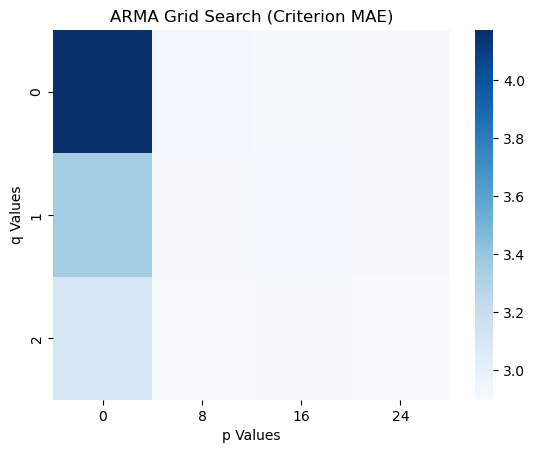

In [24]:
sns.heatmap(mae_df,cmap='Blues')
plt.xlabel("p Values")
plt.ylabel("q Values")
plt.title("ARMA Grid Search (Criterion MAE)");

## Final Model Evaluation

Based on the grid search, an ARMA(8,1) model appears to offer a good balance of accuracy and computational cost. We proceed with this model for our final evaluation.

### Residual Analysis
Before final evaluation, we examine the model's residuals (the differences between predicted and actual values). An ideal model will have residuals that are randomly distributed around zero, with no discernible patterns. The diagnostic plots for our chosen ARMA(8,1) model confirm that the residuals approximate white noise, indicating a good model fit.

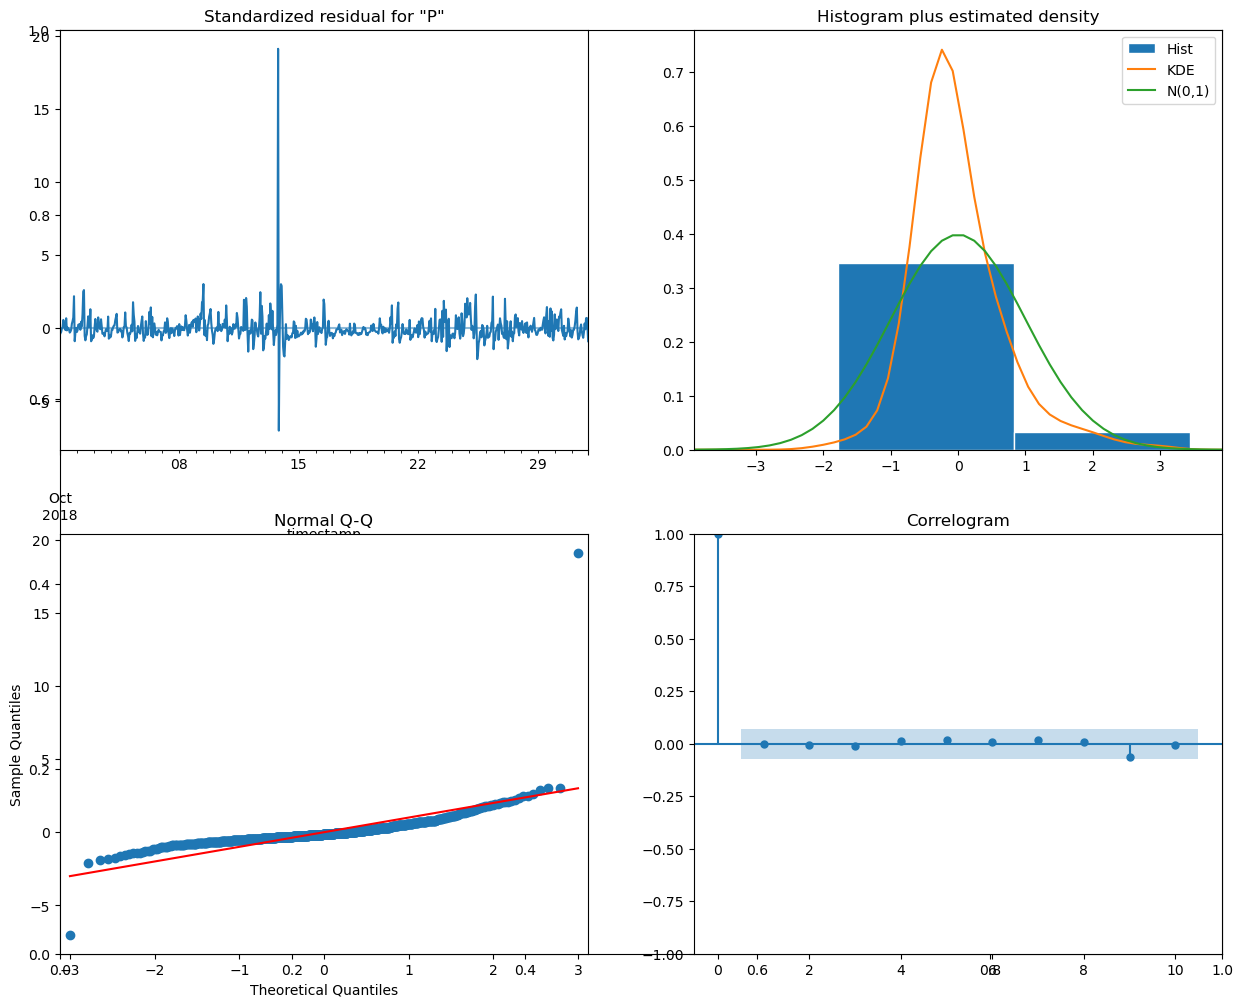

In [25]:
final_model = ARIMA(y_train, order=(8, 0, 1)).fit()
fig, ax = plt.subplots(figsize=(15, 12))
final_model.plot_diagnostics(fig=fig);

### Walk-Forward Validation
The most rigorous method for evaluating a time-series model is walk-forward validation (WFV). In this process, the model makes a one-step-ahead forecast, then the actual observation for that step is added to the training data, and the model is re-trained before making the next forecast. This simulates a real-world scenario where the model continuously learns as new data becomes available. We perform WFV on our entire test set.

In [28]:
# Walk-forward validation for ARMA(8,1)
preds = []
history = y_train.copy()
for i in range(len(y_test)):
    model = ARIMA(history, order=(8, 0, 1)).fit()
    next_pred = model.forecast()
    preds.append(next_pred.iloc[0])
    # Append the actual observed value to history for next step
    history = pd.concat([history, pd.Series(y_test.iloc[i], index=[y_test.index[i]])])

# Create a Series with the same index as y_test
y_pred_wfv = pd.Series(preds, index=y_test.index)

## Key Findings & Results

The walk-forward validation provides the most realistic estimate of the model's performance on unseen data. Our final ARMA(8,1) model achieves a significantly lower Mean Absolute Error than the baseline, demonstrating its effectiveness.

In [29]:
test_mae = mean_absolute_error(y_test, y_pred_wfv)
print("Test MAE (Walk-Forward Validation):", round(test_mae, 2))

Test MAE (Walk-Forward Validation): 1.67


To visualize the model's performance, we plot its predictions against the actual PM2.5 values for the test period. The plot shows that our model's predictions closely track the true values, capturing the fluctuations in air quality with high fidelity.

In [30]:
df_predictions = pd.DataFrame(
    {"y_test":y_test , 'y_pred_wfv': y_pred_wfv}
)

fig = px.line(df_predictions, labels={"value": "PM2.5", "timestamp": "Time"})
fig.update_layout(title_text="Nairobi PM2.5 Forecast vs. Actuals", yaxis_title="PM2.5")
fig.show()

## Business Implications & Recommendations

The successful development of this ARMA model has direct and valuable implications:

1.  **Public Health:** The model can serve as the engine for a public health alert system. By accurately forecasting PM2.5 levels an hour in advance, authorities can issue warnings to the public, especially vulnerable populations, allowing them to take protective measures like staying indoors or wearing masks.

2.  **Environmental Policy:** Consistent, accurate air quality data and forecasts can help policymakers understand pollution patterns, identify sources, and evaluate the effectiveness of environmental interventions.

3.  **Scalability:** The methodology developed in this project is scalable and can be applied to data from other sensors across Nairobi or in other cities, creating a comprehensive air quality monitoring and forecasting network.

**Recommendation:** We recommend the deployment of the ARMA(8,1) model into a production environment to provide real-time hourly forecasts for PM2.5 levels at the sensor location.

## Future Work & Next Steps

While the current model is robust, there are several avenues for future improvement:

-   **Multivariate Models:** Incorporate other relevant variables, such as weather data (temperature, humidity, wind speed) or traffic data, by using more advanced models like SARIMAX or vector autoregression (VAR).
-   **Advanced Architectures:** Explore machine learning and deep learning models, such as LSTMs (Long Short-Term Memory networks), which are specifically designed for sequence prediction and may capture more complex, non-linear patterns.
-   **Expanded Geographic Scope:** Apply the modeling process to other sensor sites to build a city-wide forecasting system.

## Conclusion

This project successfully demonstrates the power of time-series analysis in addressing a critical public health issue. By systematically progressing from data wrangling to advanced modeling and rigorous evaluation, we have developed a reliable ARMA model capable of forecasting hourly PM2.5 concentrations in Nairobi. The resulting tool not only achieves strong technical performance but also offers tangible value for public health and environmental management. The framework established here provides a solid foundation for future enhancements and broader application.

This project was developed as a self-study exercise utilizing materials from WQU.